In [1]:
#Import the petting zoo environment and evaluate
from Multi_Ag_Environment import CustomEnvironment
from pettingzoo.test import parallel_api_test
import gymnasium as gym
env = CustomEnvironment()
parallel_api_test(env, num_cycles=1_000_000)

Contact Plan Formatting
1
1
1
Initial Satellite Observations
[59, 32, 27]
Initial Satellite Observations
[59, 32, 27]
Initial Satellite Observations
[59, 32, 27]
Contact Plan Formatting
1
0
1
Initial Satellite Observations
[35, 33, 22]
Initial Satellite Observations
[35, 33, 22]
Initial Satellite Observations
[35, 33, 22]
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
2
Satellite successfully delivers data
{'satellite1': 2.3333333333333335}
{'satellite1': 2, 'satellite2': 0, 'satellite3': 0}
4
Satellite successfully delivers data
{'satellite1': 2.3333333333333335, 'satellite2': 0, 'satellite3': 1.0}
1
2
3
{'satellite1': 2, 'satellite2': 0, 'satellite3': 4}
3
Satellite successfully delivers data
{'satellite1': 1.5}
4
5
{'satellite1': 5, 'satellite2': 0, 'satellite3': 4}
0
Satellite successfully delivers data
{'satellite1': 9.0}
6
7
8
9
10
11
{'satellite1': 5, 'satellite2': 0, 'satellite3': 4}
1
Satellite successfully delivers data
{'satellite1': 4.0}
12
13
14
15
16
Contact Plan F

In [2]:
#Basic Random Policy
import random
import numpy as np
# Initialize the env
env = CustomEnvironment()
num_of_episodes=10
episode_rewards=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_rewards = {agent: [] for agent in all_agents}
# Track done flags
for episodes in range(num_of_episodes):
    obs, info = env.reset()
    
    print(obs)
    print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    total_rewards = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        for agent, r in rewards.items():
            total_rewards[agent] += r
        
        print("Rewards")
        print(rewards)
    env.close()
    for agent in all_agents:
        agent_rewards[agent].append(total_rewards.get(agent, 0))
    episode_rewards.append(np.mean(list(total_rewards.values())))

Contact Plan Formatting
1
1
0
Initial Satellite Observations
[21, 80, 27]
Initial Satellite Observations
[21, 80, 27]
Initial Satellite Observations
[21, 80, 27]
{'satellite1': {'central_observation_matrix': [[0.25064888789480366, 10, 1, 1, 0], [0.3011215284356691, 10, 0, 1, 0], [0.6545526917408019, 10, 1, 0, 0], [0.8109226798030914, 10, 1, 1, 1], [0.30621452536244, 10, 0, 1, 0], [0.5062448863982724, 10, 1, 0, 0], [0.9172468100192832, 10, 1, 1, 0], [0.36324622574918897, 10, 1, 0, 0], [0.7023655482666735, 10, 1, 1, 1], [0.9688937507265186, 10, 0, 1, 1], [0.5881390607040887, 10, 1, 1, 1], [0.7131246607787846, 10, 1, 1, 0], [0.4121376465243415, 10, 0, 1, 1], [0.09276598375626133, 10, 0, 0, 1], [0.51711714704298, 10, 0, 0, 1], [0.908495518518832, 10, 1, 0, 0], [0.7990519039304655, 10, 0, 0, 1], [0.4215889322107341, 10, 0, 0, 1], [0.010477473209536736, 10, 0, 0, 1], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 0, 0], [-1, -1, 0, 

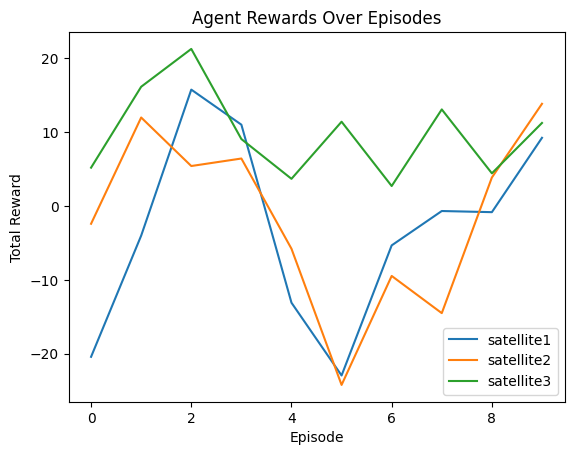

In [3]:
import matplotlib.pyplot as plt

for agent, rewards in agent_rewards.items():
    plt.plot(rewards, label=agent)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Agent Rewards Over Episodes")
plt.legend()
plt.show()

In [7]:
#Next we must display the delivery graphs along with critical performance metrics
env = CustomEnvironment()
num_of_episodes=10
episode_delivery_ratios=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_delivery = {agent: [] for agent in all_agents}
total_delivery_ratio=None
# Track done flags
for episodes in range(num_of_episodes):
    observations,info = env.reset()
    #print(observations)
    #print("Info")
    #print(info)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    initial_packets_to_deliver={agent: None for agent in all_agents}
    
    for a in all_agents:
        agent_info=info[a]
        initial_packets_to_deliver[a]=agent_info['satellite_initial_data_volume']
    delivered_packets = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        #print(infos)
        
        if any(terminated[a]==True or truncated[a]==True for a in all_agents):
            for agent in all_agents:
                agent_info=infos[agent]
                print(delivered_packets)
                print(agent_info['satellite_delivered_packets'])
                delivered_packets[agent] += agent_info['satellite_delivered_packets']
                print("Delivered packets for this episode")
                print(delivered_packets[agent])
    env.close()
    
    for agent in all_agents:
        agent_delivery[agent].append(delivered_packets[agent])
    #episode_delivery_ratios.append(np.mean(list(delivered_packets.values())))

Contact Plan Formatting
1
1
1
Initial Satellite Observations
[98, 70, 16]
Initial Satellite Observations
[98, 70, 16]
Initial Satellite Observations
[98, 70, 16]
0
{'satellite1': 0, 'satellite2': 0, 'satellite3': 0}
10
{'satellite1': 10, 'satellite2': 0, 'satellite3': 0}
10
{'satellite1': 10, 'satellite2': 10, 'satellite3': 0}
2
Satellite successfully delivers data
{'satellite1': -10, 'satellite2': -10, 'satellite3': 2.3333333333333335}
1
2
{'satellite1': 10, 'satellite2': 10, 'satellite3': 2}
10
{'satellite1': 20, 'satellite2': 10, 'satellite3': 2}
10
3
{'satellite1': 20, 'satellite2': 20, 'satellite3': 2}
10
{'satellite1': 30, 'satellite2': 20, 'satellite3': 2}
10
4
5
6
7
{'satellite1': 30, 'satellite2': 30, 'satellite3': 2}
7
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': -1, 'satellite3': 0.25}
8
{'satellite1': 30, 'satellite2': 30, 'satellite3': 9}
7
Satellite successfully delivers data
{'satellite1': 0, 'satellite2': 0.25}
{'satellite1': 30, 'satellite2': 37

{'satellite1': [14, 41, 9, 35, 18, 29, 34, 9, 23, 35], 'satellite2': [19, 15, 29, 11, 13, 24, 19, 49, 30, 12], 'satellite3': [16, 21, 48, 28, 26, 36, 41, 37, 52, 41]}


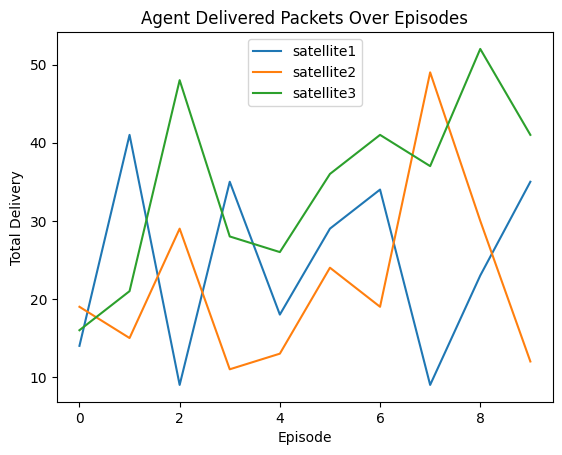

In [8]:
                      
#Next create the graph the delivery ratios
print(agent_delivery)
for agent, delivery in agent_delivery.items():
    plt.plot(delivery, label=agent)
plt.xlabel("Episode")
plt.ylabel("Total Delivery")
plt.title("Agent Delivered Packets Over Episodes")
plt.legend()
plt.show()




In [ ]:
#Next we must consider the energy efficiency and expenditure graphs
env = CustomEnvironment()
num_of_episodes=10
episode_energy_expenditure=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
agent_energy_expenditure = {agent: [] for agent in all_agents}
total_energy_expenditure=None
# Track done flags
for episodes in range(num_of_episodes):
    observations = env.reset()
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    energy_expended = {agent: None for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        for agent, energy in info.:
            agent_energy_expenditure[agent] += delivery
    env.close()

for agent in all_agents:
    total_energy_expenditure[agent].append(agent_energy_expenditure[agent])

In [ ]:
#Finally we must consider the number of collisions during an episode
env = CustomEnvironment()
num_of_episodes=10
episode_collisions=[]
# Use a fixed agent list
all_agents = ["satellite1", "satellite2", "satellite3"]
num_of_collisions=0
# Track done flags
for episodes in range(num_of_episodes):
    observations = env.reset()
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    
    delivered_packets = {agent: None for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        #print("Agent Actions")
        #print(actions)
        observations, rewards, terminated, truncated, infos = env.step(actions)
        for agent, delivery in info.:
            collisions[agent] += collision
    env.close()
    for agent in all_agents:
        agent_collisions[agent].append(collisions)
    episode_collisions.append(np.mean(list(collision.values())))


In [ ]:
#CGR
#Here we introduce CGR which will always choose Action one regardless of the weather conditions
observations = env.reset()

all_agents = ["satellite1", "satellite2", "satellite3"]

terminated = {agent: False for agent in all_agents}
truncated = {agent: False for agent in all_agents}

while not all([terminated[a] or truncated[a] for a in all_agents]):
    actions = {
        agent:1
        for agent in all_agents
        if not (terminated[agent] or truncated[agent])
    }
    print("Agent Actions")
    print(actions)
    observations, rewards, terminated, truncated, infos = env.step(actions)
    print("Rewards")
    print(rewards)
env.close()





In [ ]:
#Heuristic Baseline


observations,info = env.reset()
print(observations.keys()) 
#Satellite 1 observation
satellite1_observation=observations["satellite1"]
print(satellite1_observation)
satellite2_observation=observations["satellite2"]
print(satellite2_observation)

In [ ]:
#Next we need to conduct the initial contact selection based upon the initial state
initial_contact_plan=observations.
initial_data_volume=



for i in range(number_of_contacts):
    

all_agents = ["satellite1", "satellite2", "satellite3"]


terminated = {agent: False for agent in all_agents}
truncated = {agent: False for agent in all_agents}

while not all([terminated[a] or truncated[a] for a in all_agents]):
    
    
    actions = {
        agent:
        for agent in all_agents
        if not (terminated[agent] or truncated[agent])
    }
    print("Agent Actions")
    print(actions)
    observations, rewards, terminated, truncated, infos = env.step(actions)
    print("Rewards")
    print(rewards)
env.close()

In [ ]:
import os

import ray
import supersuit as ss
from ray import tune
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.rllib.models import ModelCatalog
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2
from ray.tune.registry import register_env
from torch import nn

#from pettingzoo.butterfly import pistonball_v6


class CNNModelV2(TorchModelV2, nn.Module):
    def __init__(self, obs_space, act_space, num_outputs, *args, **kwargs):
        TorchModelV2.__init__(self, obs_space, act_space, num_outputs, *args, **kwargs)
        nn.Module.__init__(self)
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, [8, 8], stride=(4, 4)),
            nn.ReLU(),
            nn.Conv2d(32, 64, [4, 4], stride=(2, 2)),
            nn.ReLU(),
            nn.Conv2d(64, 64, [3, 3], stride=(1, 1)),
            nn.ReLU(),
            nn.Flatten(),
            (nn.Linear(3136, 512)),
            nn.ReLU(),
        )
        self.policy_fn = nn.Linear(512, num_outputs)
        self.value_fn = nn.Linear(512, 1)

    def forward(self, input_dict, state, seq_lens):
        model_out = self.model(input_dict["obs"].permute(0, 3, 1, 2))
        self._value_out = self.value_fn(model_out)
        return self.policy_fn(model_out), state

    def value_function(self):
        return self._value_out.flatten()


def env_creator(args):
    env = CustomEnvironment()
    #env = ss.color_reduction_v0(env, mode="B")
    #env = ss.dtype_v0(env, "float32")
    #env = ss.resize_v1(env, x_size=84, y_size=84)
    #env = ss.normalize_obs_v0(env, env_min=0, env_max=1)
    #env = ss.frame_stack_v1(env, 3)
    return env


if __name__ == "__main__":
    ray.init()

    env_name = "CustomEnvironment"

    register_env(env_name, lambda config: ParallelPettingZooEnv(env_creator(config)))
    ModelCatalog.register_custom_model("CNNModelV2", CNNModelV2)

    config = (
    PPOConfig()
    .environment(env=env_name, clip_actions=True)
    .env_runners(num_env_runners=4, rollout_fragment_length=128)
    .training(
        train_batch_size=512,
        lr=2e-5,
        gamma=0.99,
        lambda_=0.9,
        use_gae=True,
        clip_param=0.4,
        grad_clip=None,
        entropy_coeff=0.1,
        vf_loss_coeff=0.25,
    )
    .framework("torch")
    .debugging(log_level="ERROR")
    .resources(num_gpus=int(os.environ.get("RLLIB_NUM_GPUS", "0")))
    .update_from_dict({
        "num_sgd_iter": 10,
        "sgd_minibatch_size": 64,  # ✅ correct place
    })
)

    tune.run(
        "PPO",
        name="PPO",
        stop={"timesteps_total": 5000000 if not os.environ.get("CI") else 50000},
        checkpoint_freq=10,
        storage_path="~/ray_results/" + env_name,
        config=config.to_dict(),
    )